<a href="https://colab.research.google.com/github/Alenushka2013/Python_Data_Science/blob/master/230210_2_3_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Інструменти для дослідження графових структур

In [6]:
!pip install networkx

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

Степінь вузлів: {'Alice': 3, 'Bob': 2, 'Charlie': 2, 'Diana': 3}


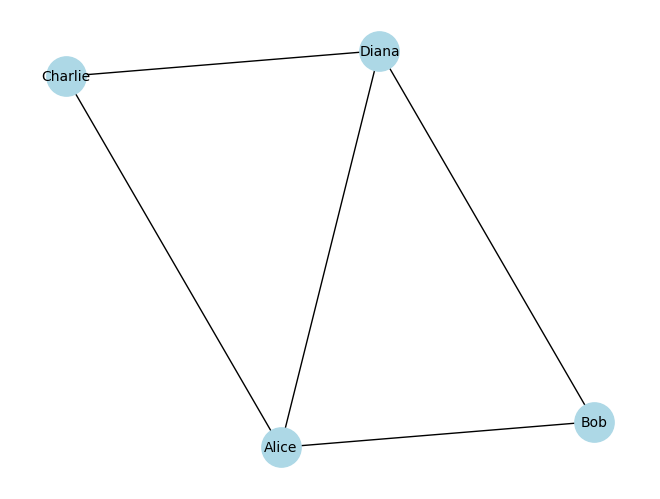

In [9]:
# Створення напрямленого графа
G = nx.Graph()

# Додавання вузлів
G.add_nodes_from(["Alice", "Bob", "Charlie", "Diana"])

# Додаваня ребер
G.add_edges_from([
    ("Alice", "Bob"),
    ("Alice", "Charlie"),
    ("Bob", "Diana"),
    ("Alice", "Diana"),
    ("Charlie", "Diana")])

# Виведення степеню кожного вузла
print("Степінь вузлів:", dict(G.degree()))

# Візуалізація графу
nx.draw(G, with_labels = True, node_color = "lightblue", node_size = 800, font_size = 10)
plt.show()

In [11]:
# Найкоротший шлях між двома вузлами
shortest_path = nx.shortest_path(G, source = "Bob", target = "Charlie")
print("Найкоротший шлях між Bob i Charlie", shortest_path)

Найкоротший шлях між Bob i Charlie ['Bob', 'Alice', 'Charlie']


Ваги ребер {('A', 'B'): 1, ('A', 'C'): 2, ('B', 'C'): 2}
Найкоротший шлях по вагам {'A': ['A'], 'B': ['A', 'B'], 'C': ['A', 'C']}


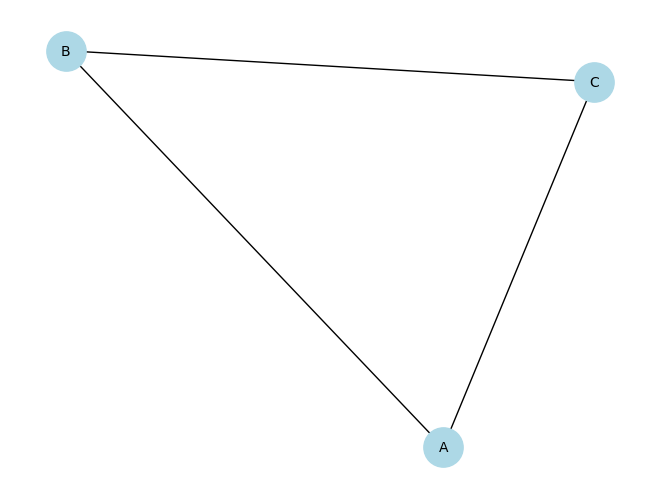

In [12]:
# Зважений граф
G = nx.Graph()
G.add_edge("A", "B", weight = 1)
G.add_edge("B", "C", weight = 2)
G.add_edge("A", "C", weight = 2)

# Отримання вагів ребер
weights = nx.get_edge_attributes(G, 'weight')
print("Ваги ребер", weights)

# Обчислення найкоротшого шляху з урахуванням вагів
shortest_weightes_path = nx.shortest_path(G, source = "A", weight = "weight")
print("Найкоротший шлях по вагам", shortest_weightes_path)

# Візуалізація графа
nx.draw(G, with_labels = True, node_color = "lightblue", node_size = 800, font_size = 10)
plt.show()

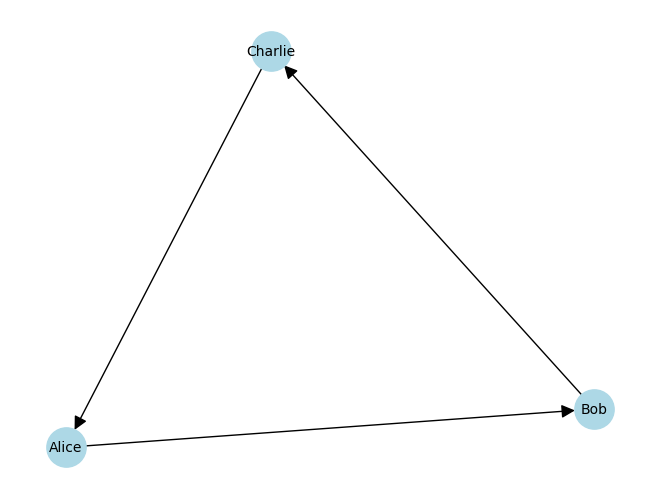

Ребра напрямленого графа: [('Alice', 'Bob'), ('Bob', 'Charlie'), ('Charlie', 'Alice')]


In [14]:
# Напярмлений граф (Directed Graph)
DG = nx.DiGraph()

# Додавання вузлів і ребер з направленнями
DG.add_edges_from([("Alice", "Bob"),
                   ("Bob", "Charlie"),
                   ("Charlie", "Alice")])
# Візуалізація направленого графа
nx.draw(DG, with_labels = True, node_color = "lightblue", node_size = 800, arrowsize = 20, font_size = 10)
plt.show()

# Вивід усіх ребер і їх напрямків
print("Ребра напрямленого графа:",  list(DG.edges))

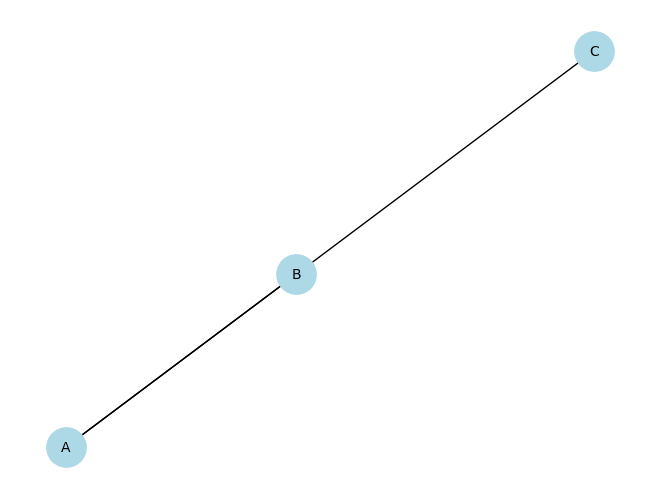

Кількість ребер між А і В 2


In [16]:
# Створення мультиреберного графа (MultiGraph)
MG = nx.MultiGraph()

# Додавання кількох ребер між однією парою вузлів
MG.add_edges_from([("A", "B"), ("B", "A"), ("B", "C")])

# Візуалізація мультиреберного графа
nx.draw(MG, with_labels = True, node_color = "lightblue", node_size = 800, font_size = 10)
plt.show()

# Кількість ребер між вузлами
print("Кількість ребер між А і В", MG.number_of_edges("A", "B"))

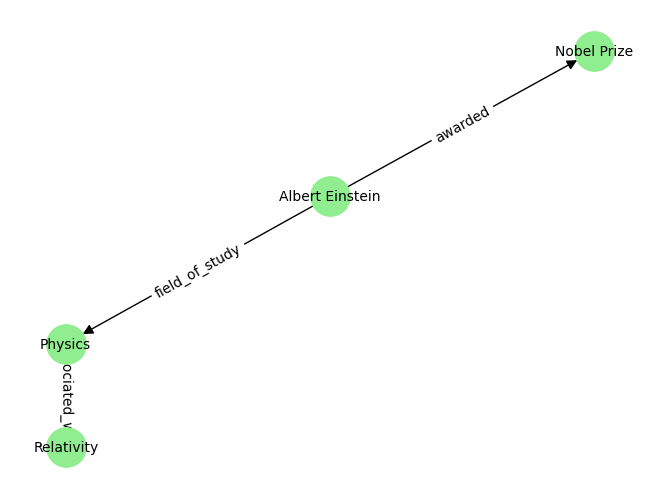

Albert Einstein -> Physics (Relation: field_of_study)
Albert Einstein -> Nobel Prize (Relation: awarded)
Physics -> Relativity (Relation: associated_with)


In [19]:
# Створення графу знань (Knowledge Graph)
KG = nx.DiGraph()

# Додавання вузлів і ребер
KG.add_edge("Albert Einstein", "Physics", relation = "field_of_study")
KG.add_edge("Albert Einstein", "Nobel Prize", relation = "awarded")
KG.add_edge("Physics", "Relativity", relation = "associated_with")

# Візуалізація графа знань
pos = nx.spring_layout(KG)
nx.draw(KG, pos, with_labels = True, node_color = "lightgreen", node_size = 800, font_size = 10, arrowsize = 15)
edge_labels = nx.get_edge_attributes(KG, "relation")
nx.draw_networkx_edge_labels(KG, pos, edge_labels)
plt.show()


# Вивід інформації про граф знань
for edge in KG.edges(data = True):
  print(f"{edge[0]} -> {edge[1]} (Relation: {edge[2]['relation']})")

## Обчислення графових метрик

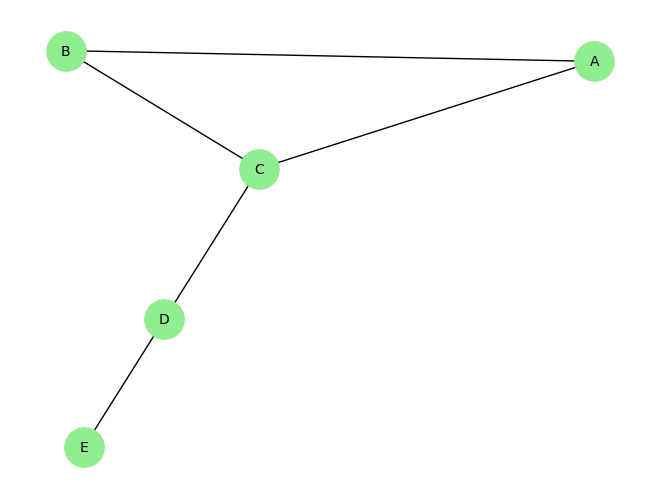

In [20]:
# Створення графу
G = nx.Graph()
G.add_edges_from([("A", "B"), ("B", "C"), ("A", "C"), ("C", "D"), ("D", "E")])

# Візуалізація  графу
nx.draw(G, with_labels = True, node_color = "lightgreen", node_size = 800, font_size = 10)
plt.show()

### Центральність вузлів

In [22]:
# Обчислення центральності по степені (degree centrality)
degree_centrality = nx.degree_centrality(G)
print("Центральність по степені:", degree_centrality)

# Обчислення центральності по близькості (closeness centrality)
closeness_centrality = nx.closeness_centrality(G)
print("Центральність по близькості:", closeness_centrality)

# Обчислення центральності по міжвузловій значущості (betweenness centrality)
betweenness_centrality = nx.betweenness_centrality(G)
print("Центральність по міжвузловій значущості:", betweenness_centrality)

Центральність по степені: {'A': 0.5, 'B': 0.5, 'C': 0.75, 'D': 0.5, 'E': 0.25}
Центральність по близькості: {'A': 0.5714285714285714, 'B': 0.5714285714285714, 'C': 0.8, 'D': 0.6666666666666666, 'E': 0.4444444444444444}
Центральність по міжвузловій значущості: {'A': 0.0, 'B': 0.0, 'C': 0.6666666666666666, 'D': 0.5, 'E': 0.0}


## Кластерний коефіцієнт

In [23]:
# Обчислення локального кластерного коефіцієнта
clustering = nx.clustering(G)
print("Кластерний коефіцієнт для кожного вузла", clustering)

# Середній кластерний коефіцієнт
average_clustering = nx.average_clustering(G)
print("Середній кластерний коефіцієнт", average_clustering)

# Коефіцієнт транзитивності
transitivity = nx.transitivity(G)
print("Коефіцієнт транзитивності", transitivity)

Кластерний коефіцієнт для кожного вузла {'A': 1.0, 'B': 1.0, 'C': 0.3333333333333333, 'D': 0, 'E': 0}
Середній кластерний коефіцієнт 0.4666666666666667
Коефіцієнт транзитивності 0.5


Резульат:

 - кластерний коефіцієнт для кожного вузла вказує, наскільки зв'язані його сусіди
 - середній кластерний коефіцієнт характеризує граф в цілому

 Інтерпретація та застовування:

 - в соціальних мережах високий кластерний коефіцієнт означає, що у друзів однієї людини є висока ймовірність бути знайомими
 - в біологічних мережах високий коефіцієнт вказує на сильні функціональні зв'язки між групами білків або молекул
 - в веб-графах мережі з високим середнім кластерним коефіцієнтом мають тенденцію до створення "кластерів" або спільнот.


## Обчисленя найкоротших шляхів

In [24]:
# Найкоротші шляхи між усіма парами вузлів
shortest_paths = dict(nx.all_pairs_shortest_path_length(G))
print("Найкоротші шляхи між усіма парами вузлів:", shortest_paths)

# Середня довжина шляху
average_path_lenght = nx.average_shortest_path_length(G)
print("Середня довжина шляху:", average_path_lenght)

Найкоротші шляхи між усіма парами вузлів: {'A': {'A': 0, 'B': 1, 'C': 1, 'D': 2, 'E': 3}, 'B': {'B': 0, 'A': 1, 'C': 1, 'D': 2, 'E': 3}, 'C': {'C': 0, 'B': 1, 'A': 1, 'D': 1, 'E': 2}, 'D': {'D': 0, 'C': 1, 'E': 1, 'B': 2, 'A': 2}, 'E': {'E': 0, 'D': 1, 'C': 2, 'B': 3, 'A': 3}}
Середня довжина шляху: 1.7


## Діаметри і радіуси графа

In [25]:
# Діаметр графа (максимальна довжина найкоротшого шляху)
diameter = nx.diameter(G)
print("Діаметр графа:", diameter)

# Радіус графа (мінімальна ексцентриситетна відстань)
radius = nx.radius(G)
print('Радіус графа:', radius)

Діаметр графа: 3
Радіус графа: 2


Результат:

- діаметр графа: максимальна відстань між двома вузлами
- радіус графа: мінімальна з максимальних відстаней від узла до інших.

## Пошук спільнот

In [26]:
from networkx.algorithms import community

# Використання алгоритму модльності для пошуку спільнот
communities = community.greedy_modularity_communities(G)

# Виведення кількості знайдених спільнот
print(f"Знайдено {len(communities)} спільнот")

# Виведення вузлів, які входять до кожної спільноти
for i , comm in enumerate(communities):
  print(f"Спільнота {i + 1}: {sorted(comm)}")

Знайдено 2 спільнот
Спільнота 1: ['A', 'B', 'C']
Спільнота 2: ['D', 'E']


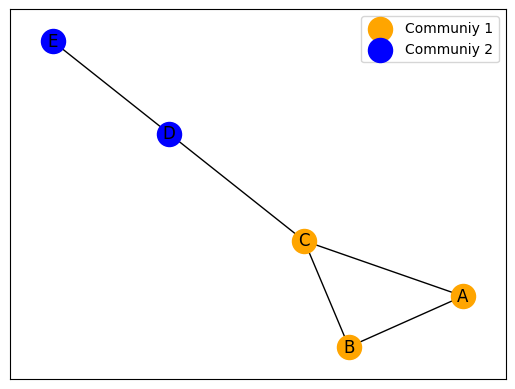

In [27]:
# Генерація кольорів
colors = ['orange', 'blue']

# Відображення графу
pos = nx.spring_layout(G)
for i, comm in enumerate(communities):
  nx.draw_networkx_nodes(G, pos, nodelist = comm, node_color = colors[i % len(colors)], label = f"Communiy {i + 1}")

nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)
plt.legend()
plt.show()

In [28]:
# Приклад
#Створення графу
G = nx.karate_club_graph()  #Класичний граф спільнот

# Запуск алгоритму модульності
communities = list(community.greedy_modularity_communities(G))

# Виведення кількості знайдених спільнот
print(f"Знайдено {len(communities)} спільнот")

# Виведення вузлів, які входять в кожну спільноту
for i , comm in enumerate(communities):
  print(f"Спільнота {i + 1}: {sorted(comm)}")

Знайдено 3 спільнот
Спільнота 1: [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Спільнота 2: [1, 2, 3, 7, 9, 12, 13, 17, 21]
Спільнота 3: [0, 4, 5, 6, 10, 11, 16, 19]


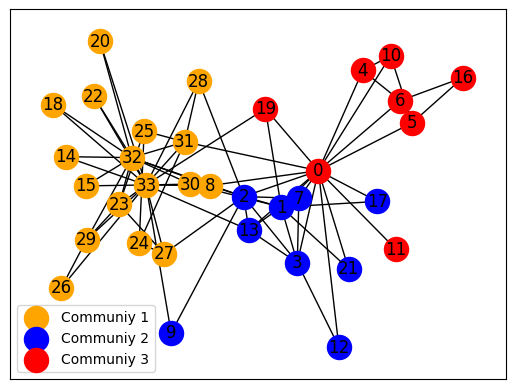

In [29]:
# Генерація кольорів
colors = ['orange', 'blue', 'red', 'green', 'purple', 'pink', 'brown', 'gray']

# Відображення графу
pos = nx.spring_layout(G)
for i, comm in enumerate(communities):
  nx.draw_networkx_nodes(G, pos, nodelist = comm, node_color = colors[i % len(colors)], label = f"Communiy {i + 1}")

nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)
plt.legend()
plt.show()

# PyTorch Geometric

In [30]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.7 MB/s eta 0:00:00


In [31]:
import torch
from torch_geometric.data import Data

# Визначення ребер графа
edge_index = torch.tensor([
    [0, 1, 1, 2, 2, 3],
    [1, 0, 2, 1, 3, 2]
    ], dtype = torch.long)
# Визначення ознак графа
x = torch.tensor([
    [1, 0],
    [0, 1],
    [1, 1]
], dtype = torch.float)

# Створення об'єкту графа
graph = Data(x = x, edge_index = edge_index)
print(graph)

Data(x=[3, 2], edge_index=[2, 6])


З допомогою PyTorch Geometric неможна візуалізувати графи. Для цього можна використовувати популярні бібліотеки, такі як Matplotlib або NetworkX спільно з даним з PyTorch Geometric.

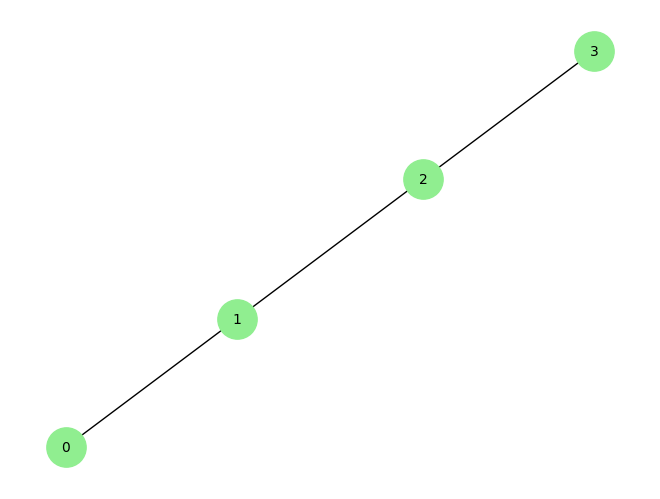

In [32]:
# Конвертація в граф  NetworkX
G = nx.Graph()
edges = graph.edge_index.t().tolist() # перетворення ребер в список
G.add_edges_from(edges)

# Візуалізація графа
nx.draw(G, with_labels = True, node_color = "lightgreen", node_size = 800, font_size = 10)
plt.show()

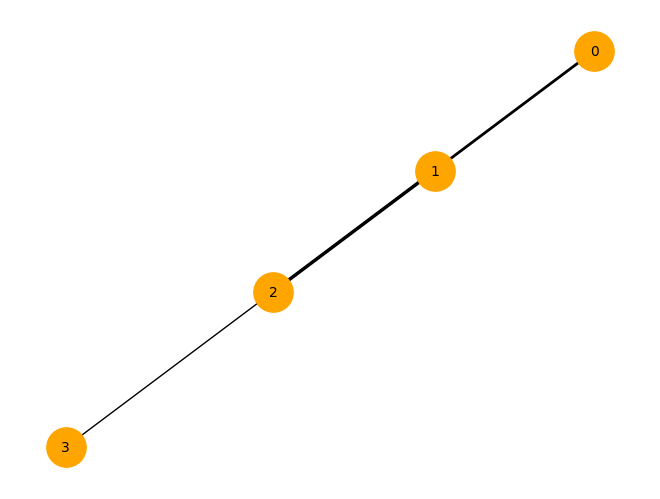

In [37]:
#Додаєм ваги ребер
edge_weights = [1.0, 2.0, 1.5, 2.5, 3.0, 1.0] # Приклад вагів
nx.set_edge_attributes(G, {tuple(edge): weight for edge, weight in zip(edges, edge_weights)}, "weights")

# Візуалізація з шириною ребер, яка відповідає вагам
pos = nx.spring_layout(G)
weights = nx.get_edge_attributes(G, "weights")
nx.draw(G, pos, with_labels = True, node_color = "orange", node_size = 800, font_size = 10, width = [weights[edge] for edge in G.edges])
plt.show()

# Завдання 1

In [38]:
# Задача: Заданий граф на основі даних "Faceb00k Social Circles"

import networkx as nx
import matplotlib.pyplot as plt
import requests
import gzip
import shutil
import os

In [39]:
# Параметри датасету (SNAP: facebook_combined)

url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
filename = "facebook_combined.txt.gz"
unzipped_filename = "facebook_combined.txt"

In [40]:
if not os.path.exists(unzipped_filename):
  response = requests.get(url, stream=True)

with open(filename, "wb") as f:
  f.write(response.content)

In [41]:
with gzip.open(filename, "rb") as f_in:
  with open(unzipped_filename, "wb") as f_out:
    shutil.copyfileobj(f_in, f_out)

In [42]:
# Завантажуємо граф
graph_data = nx.read_edgelist(unzipped_filename)


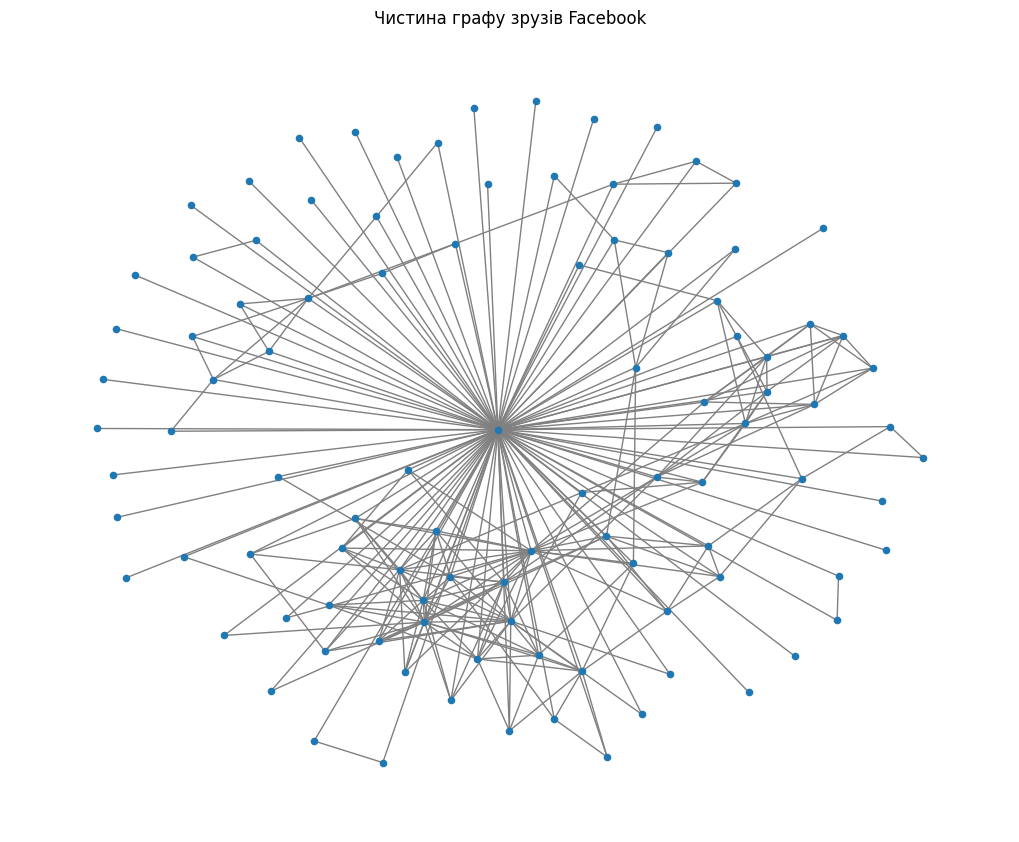

In [44]:
# Візуалізація
plt.figure(figsize=(10, 8))
subgraph = nx.subgraph(graph_data, list(graph_data.nodes)[:100]) # Виводимо підграф з 100 вузлів
nx.draw(subgraph, node_size=20, edge_color="gray", with_labels=False)
plt.title("Чистина графу зрузів Facebook")
plt.show()

Цей датасет представляює граф дружби: вузли - користувачі, ребра - дружні зв'язки. Необхідно проаналізувати даний граф і порахувати наступні статистики:

 - число вузлів
 - число ребер
 - діаметр графа
 - радіус графа
 - число спільнот


In [47]:
# число вузлів
print('число вузлів:',  graph_data.number_of_nodes())

# число ребер
print('число ребер', graph_data.number_of_edges())

число вузлів: 4039
число ребер 88234


In [45]:
# Діаметр графа (максимальна довжина найкоротшого шляху)
diameter = nx.diameter(graph_data)
print("Діаметр графа:", diameter)

# Радіус графа (мінімальна ексцентриситетна відстань)
radius = nx.radius(graph_data)
print('Радіус графа:', radius)

Діаметр графа: 8
Радіус графа: 4


In [46]:
# Запуск алгоритму модульності
communities = list(community.greedy_modularity_communities(graph_data))

# Виведення кількості знайдених спільнот
print(f"Знайдено {len(communities)} спільнот")

Знайдено 16 спільнот
